# Apple Stock

### Introduction:

We are going to use Apple's stock price.


### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv)

### Step 3. Assign it to a variable apple

In [31]:
apple = pd.read_csv('./appl_1980_2014.csv')
apple.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


### Step 4.  Check out the type of the columns

In [12]:
apple.dtypes

Date             str
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
Adj Close    float64
dtype: object

### Step 5. Transform the Date column as a datetime type

In [13]:
apple['Date'] = pd.to_datetime(apple['Date'])
apple['Date'].head()

0   2014-07-08
1   2014-07-07
2   2014-07-03
3   2014-07-02
4   2014-07-01
Name: Date, dtype: datetime64[us]

### Step 6.  Set the date as the index

In [14]:
apple = apple.set_index('Date')
apple.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


### Step 7.  Is there any duplicate dates?

In [15]:
print(apple.index.duplicated().any())

False


### Step 8.  Ops...it seems the index is from the most recent date. Make the first entry the oldest date.

In [17]:
apple = apple.sort_index()
apple.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-12,28.75,28.87,28.75,28.75,117258400,0.45
1980-12-15,27.38,27.38,27.25,27.25,43971200,0.42
1980-12-16,25.37,25.37,25.25,25.25,26432000,0.39
1980-12-17,25.87,26.00,25.87,25.87,21610400,0.40
1980-12-18,26.63,26.75,26.63,26.63,18362400,0.41


### Step 9. Get the last business day of each month

In [27]:
apple['Date'] = pd.to_datetime(apple['Date'])
apple = apple.set_index('Date')

monthly_last = apple.resample('BME').last()
monthly_last.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-31,34.25,34.25,34.13,34.13,8937600,0.53
1981-01-30,28.50,28.50,28.25,28.25,11547200,0.44
1981-02-27,26.50,26.75,26.50,26.50,3690400,0.41
1981-03-31,24.75,24.75,24.50,24.50,3998400,0.38
1981-04-30,28.38,28.62,28.38,28.38,3152800,0.44


### Step 10.  What is the difference in days between the first day and the oldest

In [29]:
first_day = apple.index.min()
oldest = apple.index.max()
diff_days = (apple.index.max() - apple.index.min()).days
print(diff_days)

12261


### Step 11.  How many months in the data we have?

In [33]:
apple['Date'] = pd.to_datetime(apple['Date'])
apple = apple.set_index('Date')

# Now run your count code:
months_count = len(apple.resample('ME').last())
print(months_count)

404


### Step 12. Plot the 'Adj Close' value. Set the size of the figure to 13.5 x 9 inches

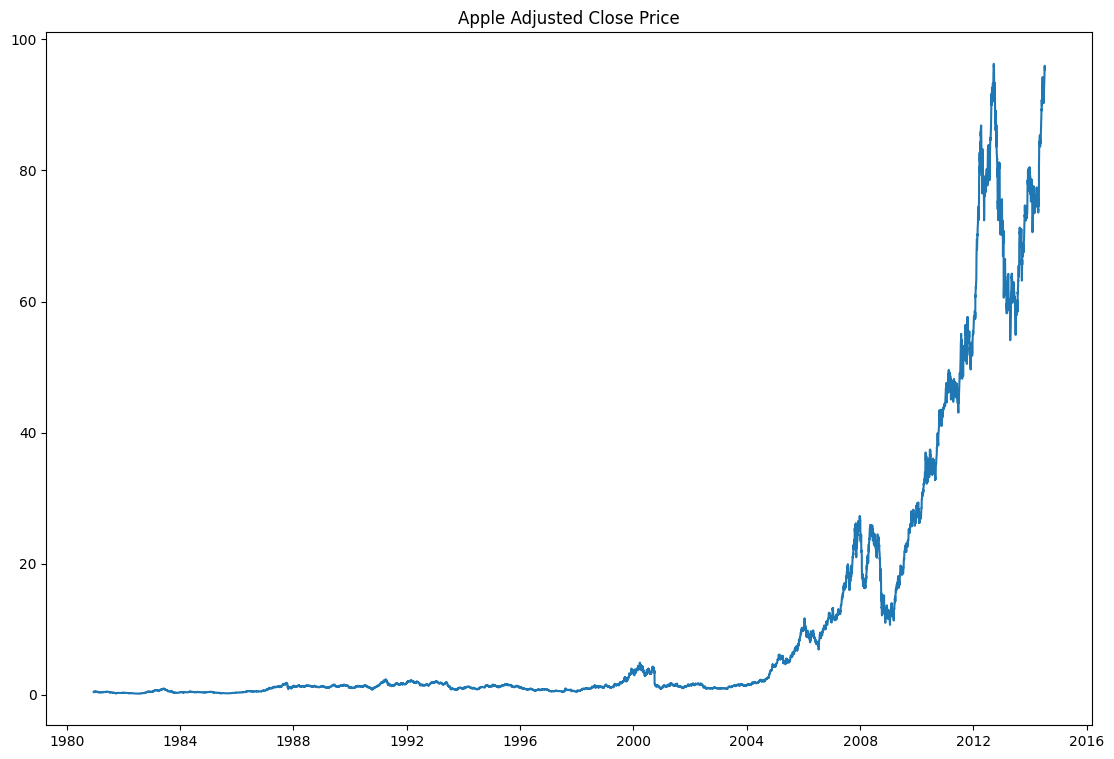

In [34]:
plt.figure(figsize=(13.5, 9))
plt.plot(apple.index, apple['Adj Close'])
plt.title('Apple Adjusted Close Price')
plt.show()

### BONUS: Create your own question and answer it.

### What is the average adjusted close for each year?

In [37]:
print(apple['Adj Close'].resample('YE').mean().head())

Date
1980-12-31    0.473077
1981-12-31    0.378651
1982-12-31    0.298261
1983-12-31    0.584643
1984-12-31    0.417787
Freq: YE-DEC, Name: Adj Close, dtype: float64
